# Hotel Booking Trends and Customer Behavior Analysis

## Step 1: Problem Definition  
Hotels often struggle with last-minute cancellations and changing customer demand. This project looks at hotel booking data to find patterns in when people book, why they cancel, and how it affects revenue. The goal is to help hotel managers understand customer behavior, reduce cancellations, and run their hotels more efficiently. By discovering what influences booking and cancellations, this project offers practical tips to improve guest satisfaction and boost profits.
## Why This is Important 
- Last-minute cancellations cause hotels to lose money.
- Knowing booking trends helps plan rooms and staff better.
- Fewer cancellations mean happier and more loyal customers.
- Understanding customer types helps create better offers and ads.
- Using data for pricing helps the hotel earn more money.
## Purpose of the Project  
This project explores hotel booking data to extract meaningful patterns about **booking timings**, **cancellation reasons**, and **revenue trends**.
The dataset used is the **Hotel Booking Demand** dataset from Kaggle:  
[Kaggle - Hotel Booking Demand Dataset](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/data)

## Main Goal of the Project
- Booking behaviors
- Factors causing cancellations
- Revenue patterns

## Adding Necessary Libraries For The Project

In [1]:
import pandas as pd         
import numpy as np           
import matplotlib.pyplot as plt 
import seaborn as sns           
import warnings
warnings.filterwarnings('ignore') 

## Step 2: Data Understanding 

##### Loading and Analyzing the Data

### Understanding the Dataset Columns

This hotel booking dataset has many columns that tell us about the bookings and customers. Here are the important columns and what they mean:

| Column Name                  | Meaning                                      |
|------------------------------|----------------------------------------------|
| `hotel`                      | Type of hotel (e.g., Resort or City hotel)  |
| `is_canceled`                | If the booking was canceled (1 = Yes, 0 = No) |
| `lead_time`                  | Days between booking and arrival             |
| `arrival_date_year`          | Year of arrival                              |
| `arrival_date_month`         | Month of arrival                             |
| `arrival_date_day_of_month`  | Day of arrival                              |
| `stays_in_weekend_nights`    | Number of weekend nights stayed             |
| `stays_in_week_nights`       | Number of weeknights stayed                  |
| `adults`                     | Number of adults                            |
| `children`                   | Number of children                          |
| `babies`                     | Number of babies                            |
| `meal`                       | Type of meal booked (like breakfast only)  |
| `country`                    | Customer’s country                         |
| `market_segment`             | Where the booking came from (e.g., online) |
| `distribution_channel`       | How the booking was made                    |
| `is_repeated_guest`          | If the guest has stayed before (1 = Yes)    |
| `previous_cancellations`     | How many bookings the customer canceled before |
| `previous_bookings_not_canceled` | How many bookings the customer did not cancel before |
| `reserved_room_type`         | Room type booked                            |
| `assigned_room_type`         | Room type given                             |
| `booking_changes`            | Number of changes made to the booking        |
| `deposit_type`               | Type of deposit made                        |
| `agent`                      | Travel agent ID who made the booking         |
| `company`                    | Company ID who made the booking               |
| `days_in_waiting_list`       | Days booking waited on the waiting list       |
| `customer_type`              | Type of customer (e.g., transient, contract) |
| `adr`                        | Average daily price of the booking           |
| `required_car_parking_spaces`| Number of parking spaces needed              |
| `total_of_special_requests`  | Number of special requests made              |

This helps you understand what each column means before starting your analysis.

In [2]:
df = pd.read_csv(r'C:\Users\kaviti Akhil\Downloads\hotel_booking.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


##### <U> Dataset Shape </U>

To check the number of rows and columns in the dataset, use the `.shape` property:

In [3]:
df.shape

(119390, 32)

#####  Dataset Summary:

Use the following command to generate a statistical summary of all **numerical features**:

In [4]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


##### Quick Data Overview:

Use the follwing command  to see a quick summary of your dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

##### <U> Dataset Features </U>
The dataset includes numeric and categorical features to predict liver disease.

##### List out continuous columns and categorical columns 

In [6]:
continuous_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
                   'adults', 'children', 'babies', 'adr', 'days_in_waiting_list', 
                   'total_of_special_requests']
categorical_cols = ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
                    'deposit_type', 'customer_type', 'reservation_status']
print("Continuous columns:", continuous_cols)
print("Categorical columns:", categorical_cols)

Continuous columns: ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'adr', 'days_in_waiting_list', 'total_of_special_requests']
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'deposit_type', 'customer_type', 'reservation_status']


##### Unique values in categorical columns

In [7]:
df[categorical_cols].nunique()

hotel                   2
arrival_date_month     12
meal                    5
country               177
market_segment          8
deposit_type            3
customer_type           4
reservation_status      3
dtype: int64

###  Categorical Column Summary

####  Hotel
- City Hotel: 79,330
- Resort Hotel: 40,060

####  Arrival Month
- August: 13,877
- July: 12,661
- May: 11,791
- October: 11,160
- April: 11,089
- June: 10,939
- September: 10,508
- March: 9,794
- February: 8,068
- November: 6,794
- December: 6,780
- January: 5,929

####  Meal Type
- BB (Bed & Breakfast): 92,310
- HB (Half Board): 14,463
- SC (Self Catering): 10,650
- FB (Full Board): 798
- Undefined: 1,169 

#### Country (Top 5)
- Portugal (PRT): 48,590
- United Kingdom (GBR): 12,129
- France (FRA): 10,415
- Spain (ESP): 8,568
- Germany (DEU): 7,287  
  Total countries: 177

####  Market Segment
- Online TA: 56,477
- Offline TA/TO: 24,219
- Groups: 19,811
- Direct: 12,606
- Corporate: 5,295
- Complementary: 743
- Aviation: 237
- Undefined: 2 

####  Deposit Type
- No Deposit: 104,641
- Non Refund: 14,587
- Refundable: 162

####  Customer Type
- Transient: 89,613
- Transient-Party: 25,124
- Contract: 4,076
- Group: 577

####  Reservation Status
- Check-Out: 75,166
- Canceled: 43,017
- No-Show: 1,207

## Step 3: Data Cleaning

#### .Treating Wrong Data

In [8]:
# Convert date column to proper date format
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
# Make sure number columns are in correct numeric type
numeric_columns = [
    'lead_time', 'arrival_date_year', 'arrival_date_week_number', 
    'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'adr', 'days_in_waiting_list',
    'required_car_parking_spaces', 'total_of_special_requests'
]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # If already correct, nothing changes
    
    
text_cols = ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
             'deposit_type', 'customer_type', 'reservation_status']

for col in text_cols:
    df[col] = df[col].astype('string')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  string        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  string        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64



|  Fix                     |  Description                                                                 |
|---------------------------|--------------------------------------------------------------------------------|
| **Date conversion**        | Converted `reservation_status_date` to proper `datetime` format using `pd.to_datetime()` |
| **Numeric type correction**| Ensured columns like `lead_time`, `adr`, `children`, etc. are in correct `int` or `float` format using `pd.to_numeric()` |
| **Text column conversion** | Converted text columns (like `hotel`, `meal`, `country`, etc.) from `object` to modern `string` type for clarity and consistency |

### .Check for Duplicate Records

#### Removing Dupliactes 

In [10]:
# to  check duplicated records 
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
119385    False
119386    False
119387    False
119388    False
119389    False
Length: 119390, dtype: bool

We use `df.duplicated()` to identify if any rows in the dataset are duplicates.

####  How it works:
- `df.duplicated()` returns a **Boolean Series** with `True` for rows that are **duplicates of a previous row**.
- The **first occurrence** of a duplicated row is marked as `False`.
- All **subsequent duplicates** are marked as `True`.

####  Example Output:
```python
df.duplicated()

In [11]:
# total number of duplicates in data 
df.duplicated().sum()

np.int64(31994)

** Goal:**  
Identify and remove any duplicate rows in the dataset.

** Code Used:**
```python
df.duplicated().sum()

### Why do the first few rows show no duplicates but total duplicates are many?

- The `df.duplicated()` function checks if each row is a duplicate of any **previous** row.
- The **first occurrence** of a row is always marked as `False` (not a duplicate) because it is unique up to that point.
- So, when you look at the first few rows with `df.head()`, you mostly see `False` values for duplicates.
- The `True` values appear **later** in the DataFrame where rows repeat an earlier row.
- Therefore, the initial rows don’t show duplicates, but when considering the entire dataset, there may be many duplicates.
- The total duplicates count given by `df.duplicated().sum()` counts **all duplicated rows in the dataset**, including those that appear much later.

#### Example:

| Row index | duplicated() value | Explanation                     |
|-----------|-------------------|--------------------------------|
| 0         | False             | First time this row appears     |
| 1         | False             | Unique row so far               |
| ...       | ...               | ...                            |
| 35000     | True              | This row duplicates a previous row |

This is why initial checks on top rows show no duplicates, but the overall dataset has many duplicate rows.

In [12]:
# to extract duplicate records 
df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,No Deposit,9.0,NaN,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


#### Extracting Duplicate Records

The code below extracts all rows that are duplicates in the dataset (excluding their first occurrence):

```python
df[df.duplicated()]

In [13]:
# to extract non duplicte records 
df[~df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [14]:
# to remove duplicates 
df=df.drop_duplicates(ignore_index=True)

In [15]:
# total number of duplicates in data 
df.duplicated().sum()

np.int64(0)

#### Is Dropping Duplicates Necessary?

- **Duplicates** can cause misleading analysis and biased results.
- If duplicates are exact copies of the same record, dropping them helps clean the data.
- However, sometimes duplicates may be valid (e.g., repeated bookings by the same customer on purpose).
- Before dropping duplicates, understand the context of your data.
- For most data analysis projects, removing exact duplicates is a good practice to ensure data quality.

**Conclusion:**  
Dropping duplicates is usually necessary, but always check if duplicates might hold meaningful information for your specific case.


### Percentage of Duplicates Dropped

- Total rows before removing duplicates: **119,390**
- Number of duplicate rows: **31,994**
- Percentage of duplicates in the dataset: **26.79%**
- Total rows after removing duplicates: **87,396**

Removing duplicates is important because it helps to avoid bias and inaccuracies caused by repeated records in your data. This ensures that your analysis reflects the true patterns without repeated noise.

### .Checking Missing Values 

In [16]:
# to check the missing value in records 
df.isnull()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,False,False,False,False,False,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87391,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
87392,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
87393,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
87394,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


The `.isnull()` function returns a DataFrame of the same shape as `df` with `True` for missing values and `False` for present values.

Example output snippet:

| hotel | is_canceled | lead_time | ... | agent  | company | ... |
|-------|-------------|-----------|-----|--------|---------|-----|
| False | False       | False     | ... | True   | True    | ... |
| False | False       | False     | ... | True   | True    | ... |
| False | False       | False     | ... | False  | True    | ... |
| ...   | ...         | ...       | ... | ...    | ...     | ... |

- Here, `True` in columns like `agent` and `company` indicates missing values in those columns.
- `False` means the data is present.
- There are 87,396 rows and 32 columns in this dataset.

In [17]:
# to check total missing values 
df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


The output below shows the count of missing values in each column:

| Column              | Missing Values |
|---------------------|----------------|
| children            | 4              |
| country             | 452            |
| agent               | 12,193         |
| company             | 82,137         |
| Other columns       | 0              |

- Most columns have no missing values.
- `children`, `country`, `agent`, and especially `company` have missing data.
- The `company` column has a large number of missing values and may require special attention.
- Next steps: Decide how to handle these missing values (e.g., fill, drop, or keep as is).

In [18]:
# to check percent of missing values in each variable 
df.isnull().sum()/len(df)*100

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.004577
babies                             0.000000
meal                               0.000000
country                            0.517186
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

In [19]:
df[df.isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaT
1,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaT
2,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaT
3,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaT
4,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87391,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaT
87392,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaT
87393,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaT
87394,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaT


- Found some rows with **all values missing** (`<NA>` or `NaN` in all columns).
- Such rows are not useful and should be removed.

#### Should We Drop Missing Values in This Project? Why?

- Dropping missing values is **not always needed**. It depends on how many values are missing and how important those columns are.
- Some columns, like **`agent`** and **`company`**, have a lot of missing data.
- Other columns, like **`children`**, have only a few missing values.
- If only a few rows have missing values, it's okay to drop those rows because it won’t affect the data much.
- But if a lot of data is missing in a column, dropping those rows will remove too much information.
- Instead of dropping, we can also:
  - Fill missing values with something meaningful (like average or zero).
  - Keep the missing values if they mean something (like no agent assigned).
  - Or remove columns that have too many missing values if they are not important.
- If rows are **completely empty**, it’s best to remove them because they don’t add any value.

**What to do here?**

- Remove rows that are empty.
- For columns with many missing values, decide if we want to fill them or remove the column.
- For columns with just a few missing values, either fill or drop those rows.

This way, we keep the data clean without losing too much useful information.


In [20]:
# Drop rows where all values are missing (NaN)
df = df.dropna(how='all')

#### Replace the missing values statistically 
#### Handling Missing Values
- For **continuous numeric data** :  
  - Use **mean** to fill missing values **if there are no outliers**.  
  - Use **median** to fill missing values **if outliers are present**.
- For **discrete or count data**:  
  - Use **mode** (most frequent value) to fill missing values.
**Why?**  
- Mean is affected by extreme values (outliers).  
- Median is better when data has outliers.  
- Mode is best for categorical or count data.
This helps keep the data clean and accurate!

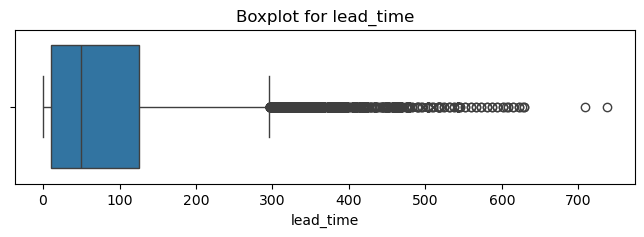

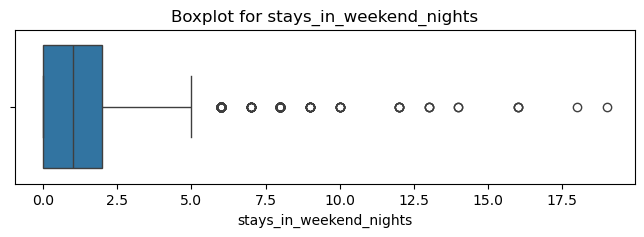

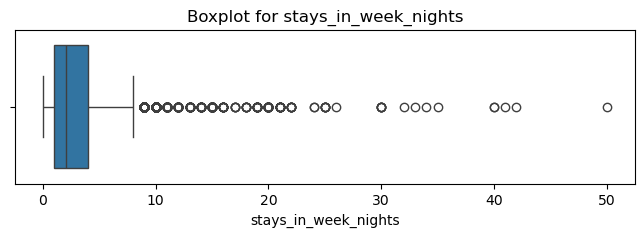

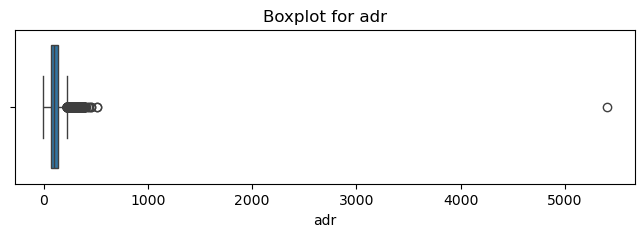

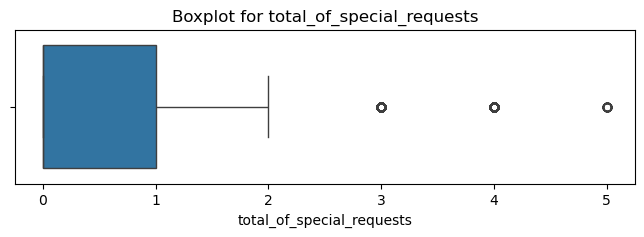


==== COLUMN: LEAD_TIME ====
Q1 11.0
Q3 125.0
IQR 114.0
Lower Limit -160.0
Upper Limit 296.0
Outliers in lead_time:
 0        342
1        737
78       368
79       364
82       324
        ... 
87222    457
87264    341
87312    303
87313    332
87348    325
Name: lead_time, Length: 2396, dtype: int64

==== COLUMN: STAYS_IN_WEEKEND_NIGHTS ====
Q1 0.0
Q3 2.0
IQR 2.0
Lower Limit -3.0
Upper Limit 5.0
Outliers in stays_in_weekend_nights:
 84        6
1088      6
1570     13
1666      6
1701      8
         ..
73910     9
75424     6
76529     6
76675    13
78723     8
Name: stays_in_weekend_nights, Length: 220, dtype: int64

==== COLUMN: STAYS_IN_WEEK_NIGHTS ====
Q1 1.0
Q3 4.0
IQR 3.0
Lower Limit -3.5
Upper Limit 8.5
Outliers in stays_in_week_nights:
 28       10
29       11
49       10
82       10
83       10
         ..
85773     9
86081    12
86597    10
86665     9
86754    10
Name: stays_in_week_nights, Length: 1531, dtype: int64

==== COLUMN: ADR ====
Q1 72.0
Q3 134.0
IQR 62.0
Lower

In [21]:
outlier_columns = [
    'lead_time', 
    'stays_in_weekend_nights', 
    'stays_in_week_nights',
    'adr', 
    'total_of_special_requests'
]
# Lets calculate outliers for continous data 
# Loop through each numeric column and plot a boxplot
for col in outlier_columns:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot for {col}')
    plt.show()
# calculate outliers 
for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    print(f"\n==== COLUMN: {col.upper()} ====") 
    print("Q1",Q1)
    print("Q3",Q3)
    print("IQR",IQR)
    print("Lower Limit",lower_limit)
    print("Upper Limit",upper_limit)  
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    print(f"Outliers in {col}:\n", outliers[col])

In [22]:
df['babies'].value_counts().sort_index()

babies
0     86482
1       897
2        15
9         1
10        1
Name: count, dtype: int64

In [23]:
df['children'].value_counts().sort_index()

children
0.0     79028
1.0      4695
2.0      3593
3.0        75
10.0        1
Name: count, dtype: int64

These columns have **fixed or limited values**, or rare values are still realistic:

| Column                        | Why We Skip Outlier Detection                             |
|-------------------------------|------------------------------------------------------------|
| `arrival_date_year`           | Only 3 values: 2015, 2016, 2017. It's not continuous.       |
| `arrival_date_week_number`    | Fixed range (1 to 52); values are valid.                   |
| `arrival_date_day_of_month`   | Always between 1–31. No outliers here.                     |
| `adults`                      | 1–3 is common; 0 or >3 might need checking, but not outlier logic. |
| `children`                    | Values like 1, 2, 3, even 10 are possible in large families. |
| `babies`                      | Mostly 0 or 1; rare values are still realistic.             |
| `required_car_parking_spaces`| Mostly 0 or 1. Outlier logic not useful.                   |
| `days_in_waiting_list`        | Long waits (e.g. 60+ days) may happen in peak seasons.     |

In [24]:
# Now replace the values 

In [25]:
cols_without_outliers = [
    'adults', 
    'children', 
    'babies', 
    'days_in_waiting_list', 
    'required_car_parking_spaces'
]
for col in cols_without_outliers:
    mean_value = df[col].mean()
    df[col].fillna(mean_value, inplace=True)

In [26]:
# Function to replace missing values
def replace_missing_values(df):
    # Replace using median for columns with outliers
    for col in outlier_columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

In [27]:
# Call the function to actually replace missing values
replace_missing_values(df)

In [28]:
# OR to quickly check if dataset has any missing values
print("Any missing values left?", df.isnull().values.any())

Any missing values left? True


In [29]:
# Check if any missing values still exist
print(df.isnull().sum())

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              0
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


In [30]:
# Fill categorical missing values

# Fill 'country' with 'Unknown'
df['country'].fillna('Unknown', inplace=True)

# Fill 'agent' and 'company' with 0 (since they are ID-type columns)
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)

In [31]:
print("Any missing values left?", df.isnull().values.any())

Any missing values left? False


In [32]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

###  Why We Don't Replace `agent`, `company`, or `country` with Median or Treat Outliers

- These columns are **categorical or ID-like**:
  - `agent` and `company` are **ID codes**, not real numerical features.
  - `country` is **categorical text** like `'USA'`, `'PRT'`, `'GBR'`.

-  Median and outlier treatment only apply to **continuous numeric columns** with real magnitude (like `adr`, `lead_time`, etc.)

-  So instead, we handle them as:
  - `country` → fill missing with `'Unknown'`
  - `agent`, `company` → fill missing with `0` or `'Unknown'`


##  Data Cleaning Summary – Hotel Booking Dataset

We performed a thorough data cleaning process to ensure high-quality, analysis-ready data. Below is a summary of each step:

---

###  Detect and Fix Wrong Data
- Ensured all columns have appropriate data types.
- Checked for impossible or incorrect values (e.g., `adults = 0`, invalid `arrival_date` entries).
- Removed or corrected such values.

---

###  Handle Duplicate Records
- Used `df.duplicated()` and `df.drop_duplicates()` to remove exact duplicate rows.

---

###  Identify and Treat Outliers
- Used **IQR (Interquartile Range)** method for numeric columns.
- Columns where outliers were detected and treated:
  - `lead_time`
  - `stays_in_weekend_nights`
  - `stays_in_week_nights`
  - `adr`
  - `total_of_special_requests`
- Replaced outlier values with **median** for those columns.

 **No Outlier Treatment Needed** for:
- `adults`: values like 1 or 3 are valid bookings.
- `children`, `babies`: family trips may have multiple children/babies.
- `days_in_waiting_list`: long waits (50+ days) are realistic.
- `required_car_parking_spaces`: 0 or 1 is normal.
- `agent`, `company`, `country`: IDs or categories — outliers not meaningful.

---

###  Handle Missing Values
- Columns with missing values were handled as follows:

| Column                        | Action Taken                            |
|------------------------------|------------------------------------------|
| `children`                   | Replaced with **median** (no outliers)   |
| `country`                    | Replaced with `'Unknown'`                |
| `agent`, `company`           | Replaced with **0**                      |
| Columns with outliers        | Replaced missing values with **median**  |

---

### Final Check:
- No missing values remain → `df.isnull().sum()` = all 0  
- Outliers treated in relevant columns  
- Data is now clean and ready for **EDA**

## Step 4: Explonatory Data Analysis

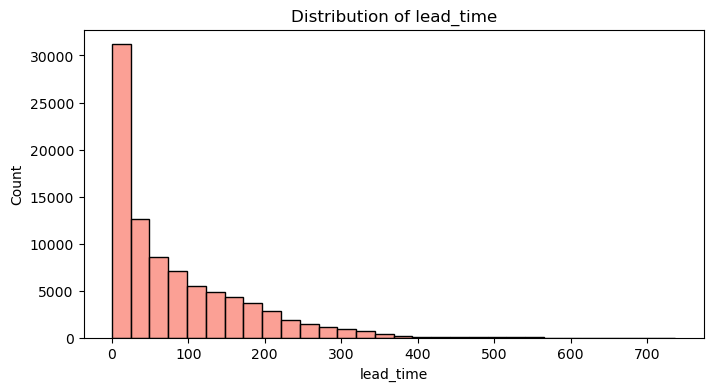

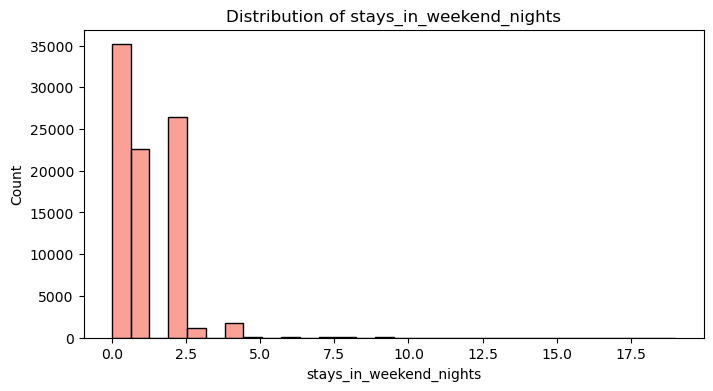

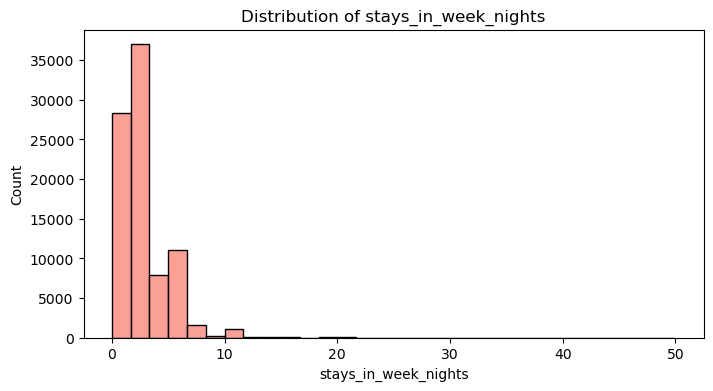

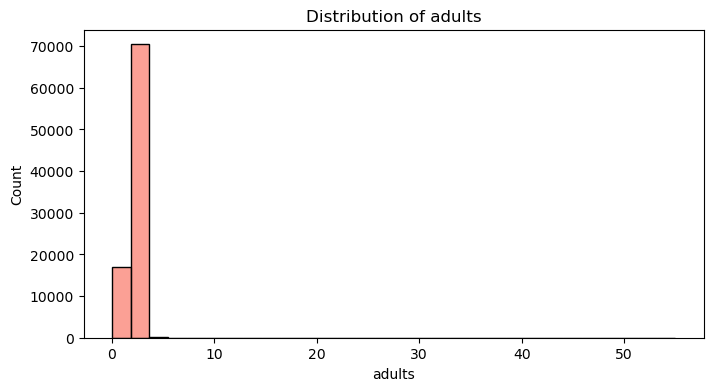

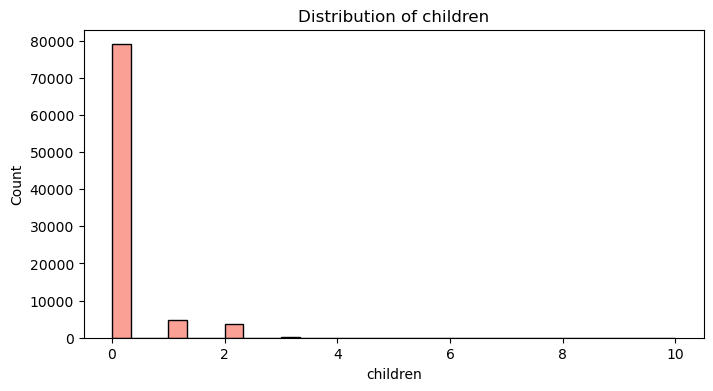

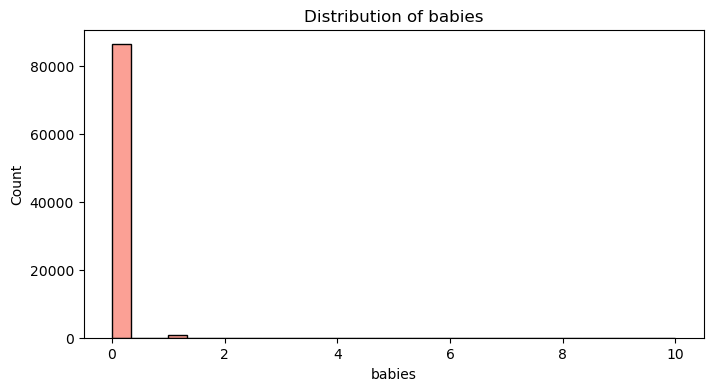

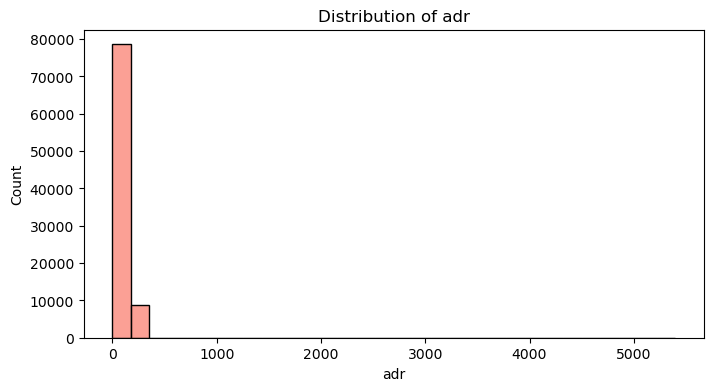

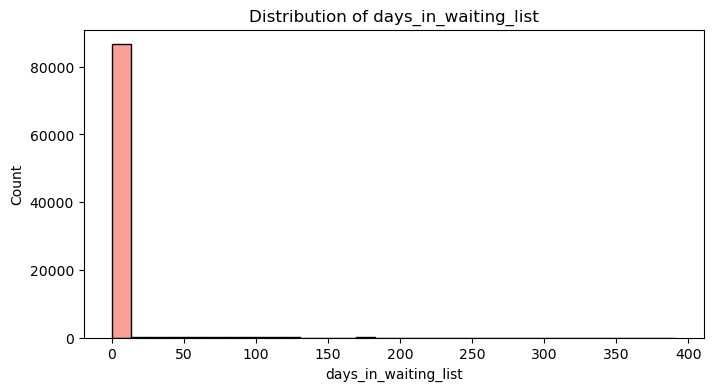

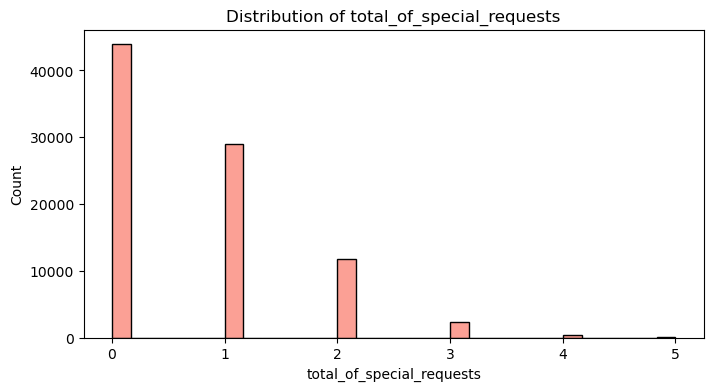

In [33]:
# Plot histograms for continuous columns
for col in continuous_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, bins=30,color="salmon")
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

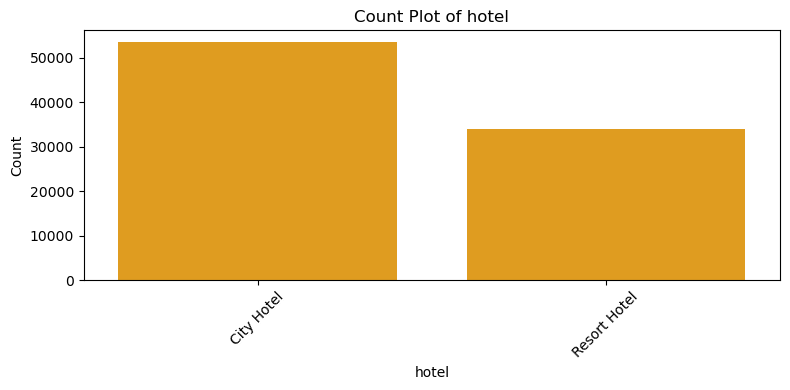

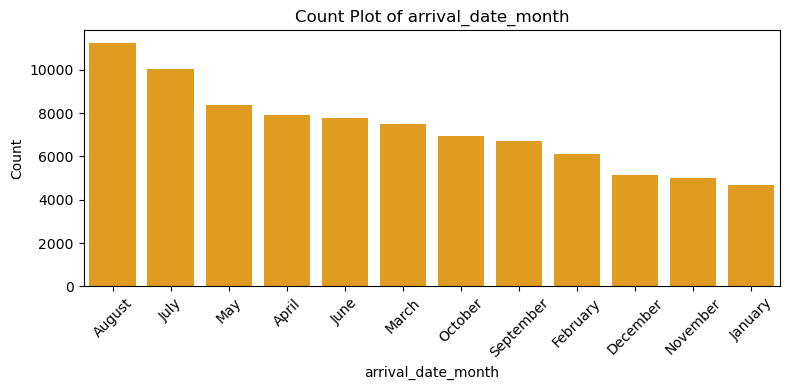

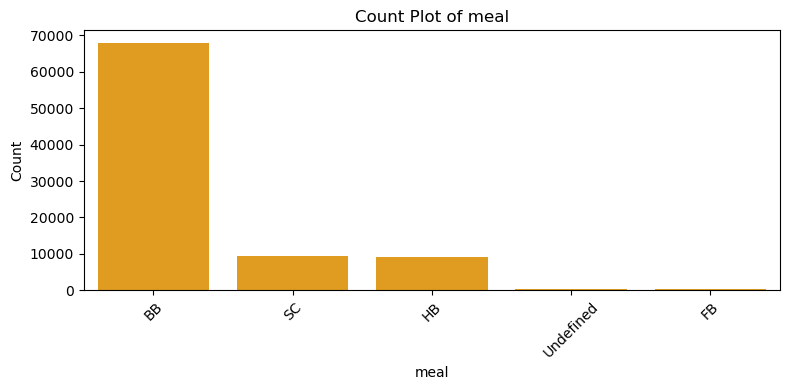

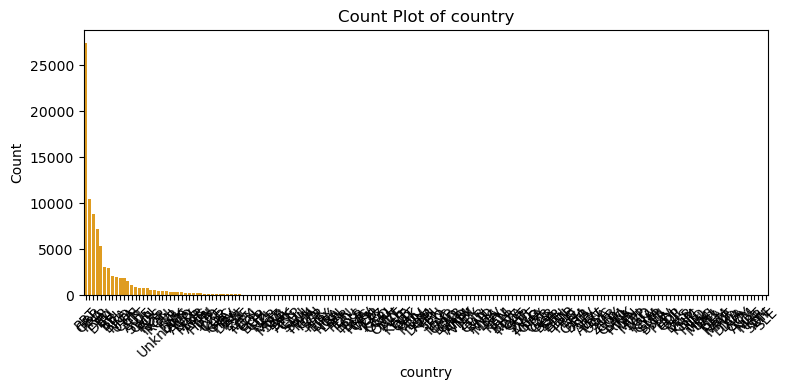

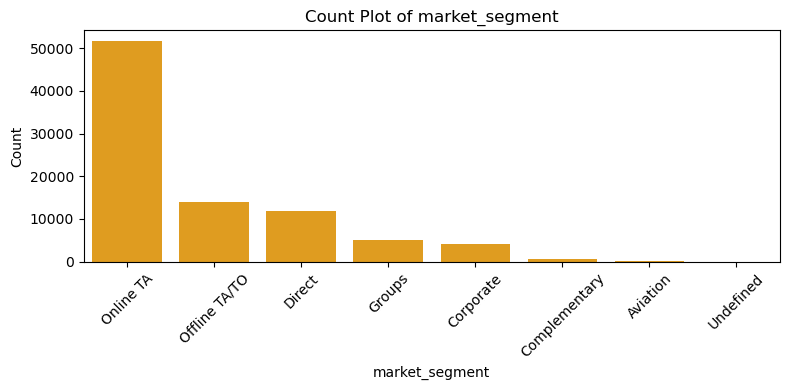

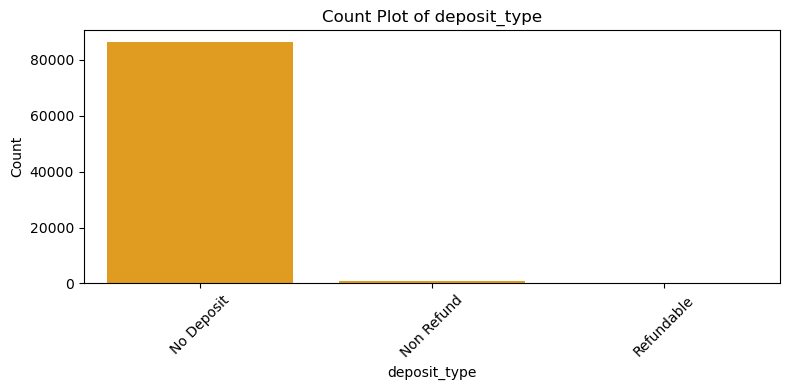

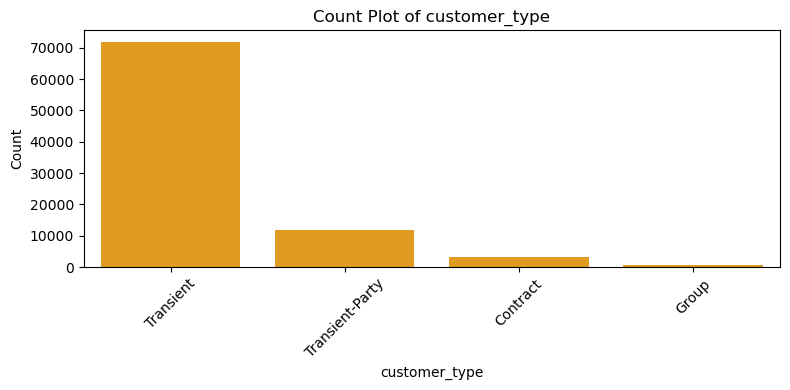

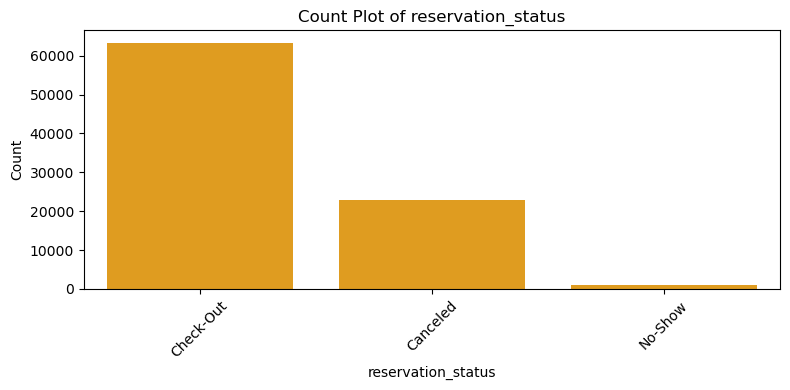

In [34]:
# Plot countplots for categorical columns
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index,color="Orange")
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

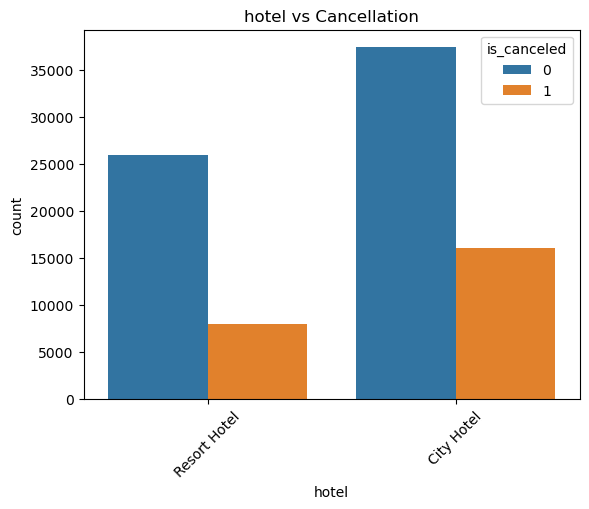

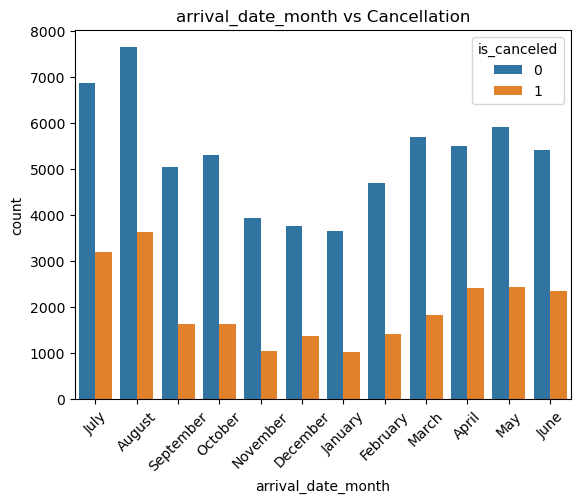

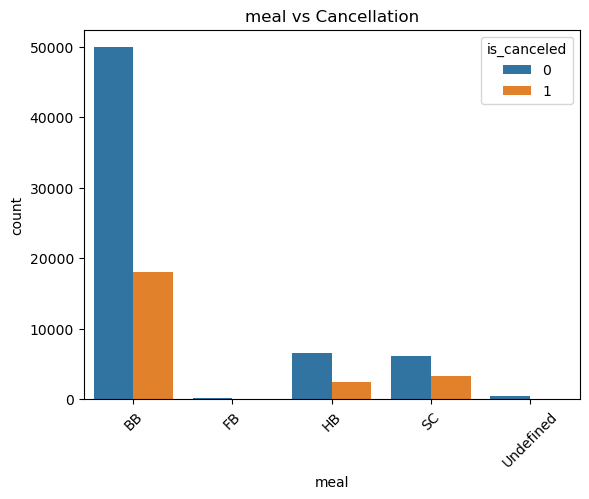

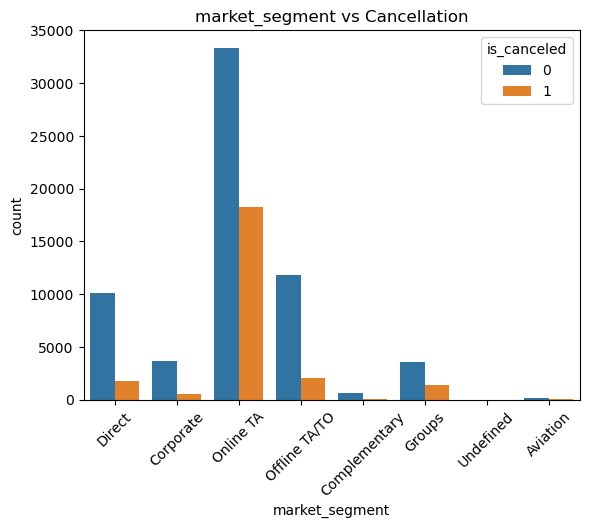

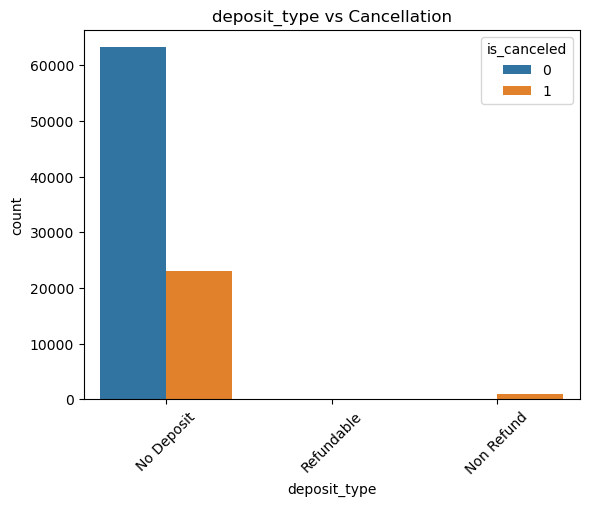

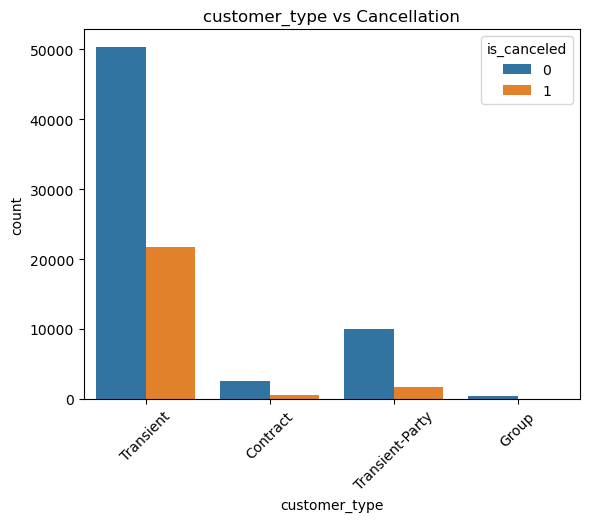

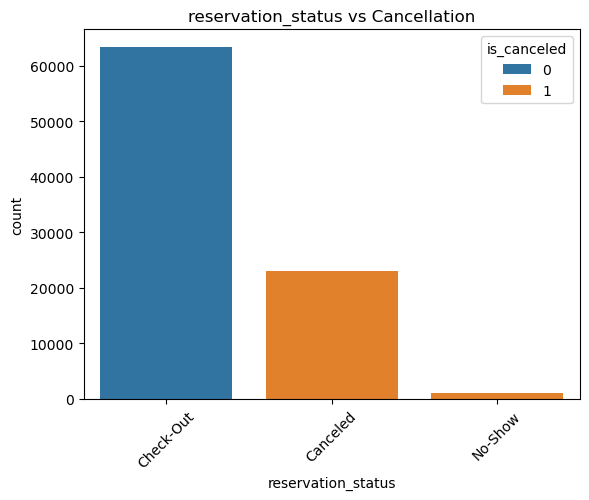

In [35]:
categorical_cols = ['hotel', 'arrival_date_month', 'meal', 'market_segment',
                    'deposit_type', 'customer_type', 'reservation_status']

for col in categorical_cols:
    sns.countplot(data=df, x=col, hue='is_canceled')
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Cancellation')
    plt.show()

###  Which Bookings Get Canceled More?

We want to check **who cancels hotel bookings** more often.

We look at columns like:
- Hotel type (City or Resort)
- Month of arrival
- Meal type
- How the customer found the hotel (market segment)
- Deposit type
- Type of customer (new, returning, etc.)
- Final booking status

These are called **categorical columns** — they contain **names or types**, not numbers.

We use a **bar chart (countplot)** to compare:
-  Bookings that did **not cancel** (`is_canceled = 0`)
-  Bookings that **got canceled** (`is_canceled = 1`)

The chart shows **two bars for each category** (one for canceled, one for not canceled).

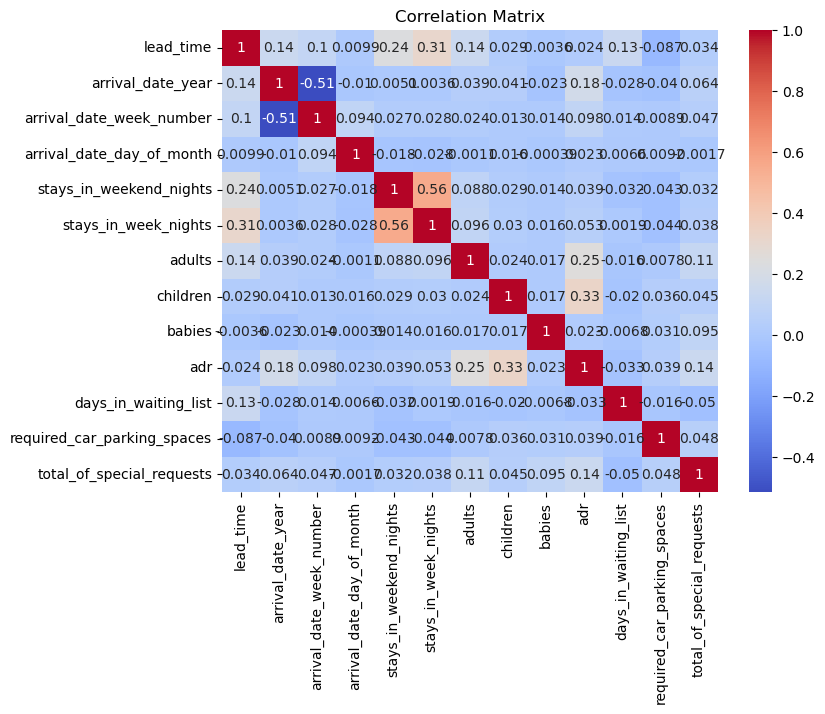

In [36]:
# Correlation heatmap for continuous variables
corr_matrix = df[numeric_columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

###  Correlation Heatmap (for Numeric Columns)
This chart shows how strongly each numeric column is related to the others.
- A value close to **1** means a strong **positive** relationship.
- A value close to **-1** means a strong **negative** relationship.
- A value near **0** means **no strong relationship**.
We use this to:
- Find patterns between columns
- Check which features may be related (or not)
- Help in feature selection for modeling
The heatmap uses colors:
-  Red = High positive relation
-  Blue = High negative relation
-  White = Weak or no relation

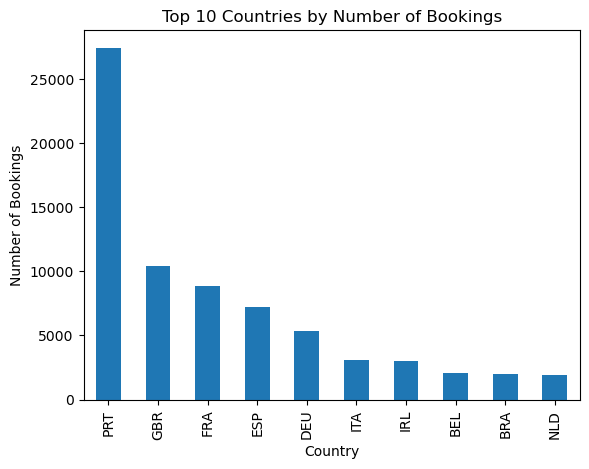

In [37]:
# Top 10 countries with most bookings
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries by Number of Bookings")
plt.ylabel("Number of Bookings")
plt.xlabel("Country")
plt.show()

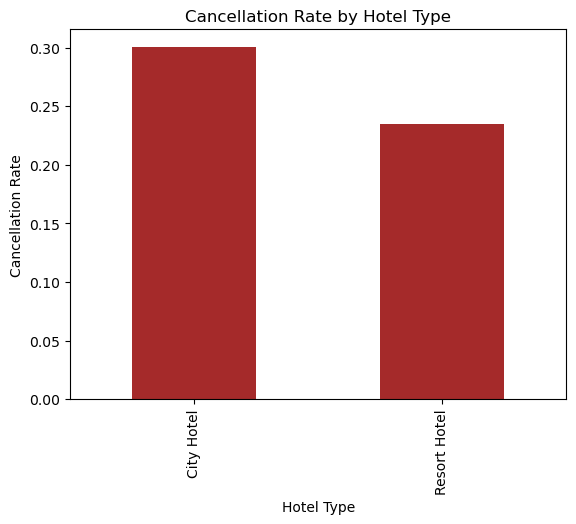

In [38]:
# Compare cancellation % by hotel
df.groupby('hotel')['is_canceled'].mean().plot(kind='bar', color='brown')
plt.title("Cancellation Rate by Hotel Type")
plt.ylabel("Cancellation Rate")
plt.xlabel("Hotel Type")
plt.show()

###  Cancellation Rate by Hotel
Shows which hotel type has more cancellations based on average `is_canceled` values.
###  Top 10 Booking Countries
Displays the top countries with the most hotel bookings.

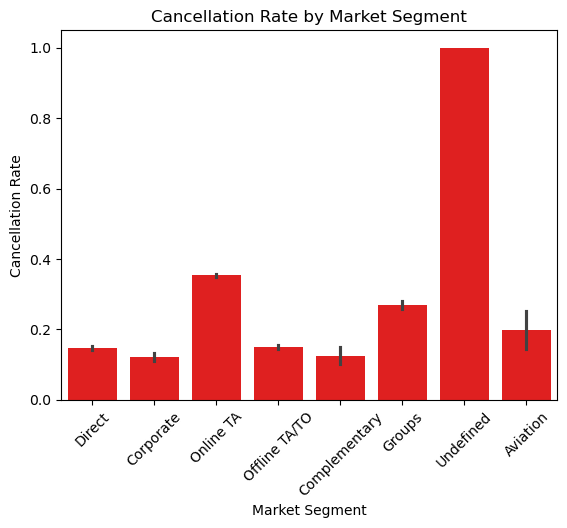

In [39]:
### Cancellation Rate by Market Segment
sns.barplot(data=df, x='market_segment', y='is_canceled',color='red')
plt.title('Cancellation Rate by Market Segment')
plt.xticks(rotation=45)
plt.ylabel('Cancellation Rate')
plt.xlabel('Market Segment')
plt.show()

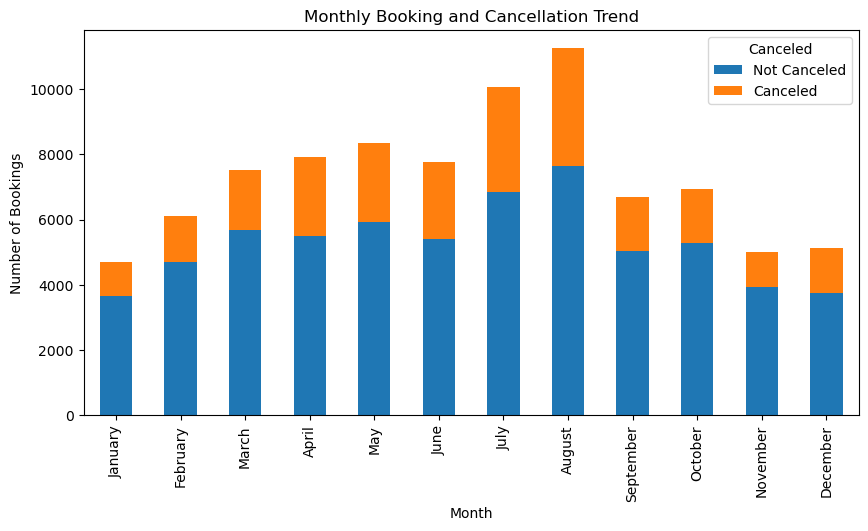

In [40]:
## which months have high bookings and how many get canceled. It’s useful for identifying seasonal patterns.
monthly_data = df.groupby('arrival_date_month')['is_canceled'].value_counts().unstack().fillna(0)
monthly_data = monthly_data.loc[['January', 'February', 'March', 'April', 'May', 'June',
                                 'July', 'August', 'September', 'October', 'November', 'December']]
monthly_data.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Monthly Booking and Cancellation Trend')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.legend(title='Canceled', labels=['Not Canceled', 'Canceled'])
plt.show()

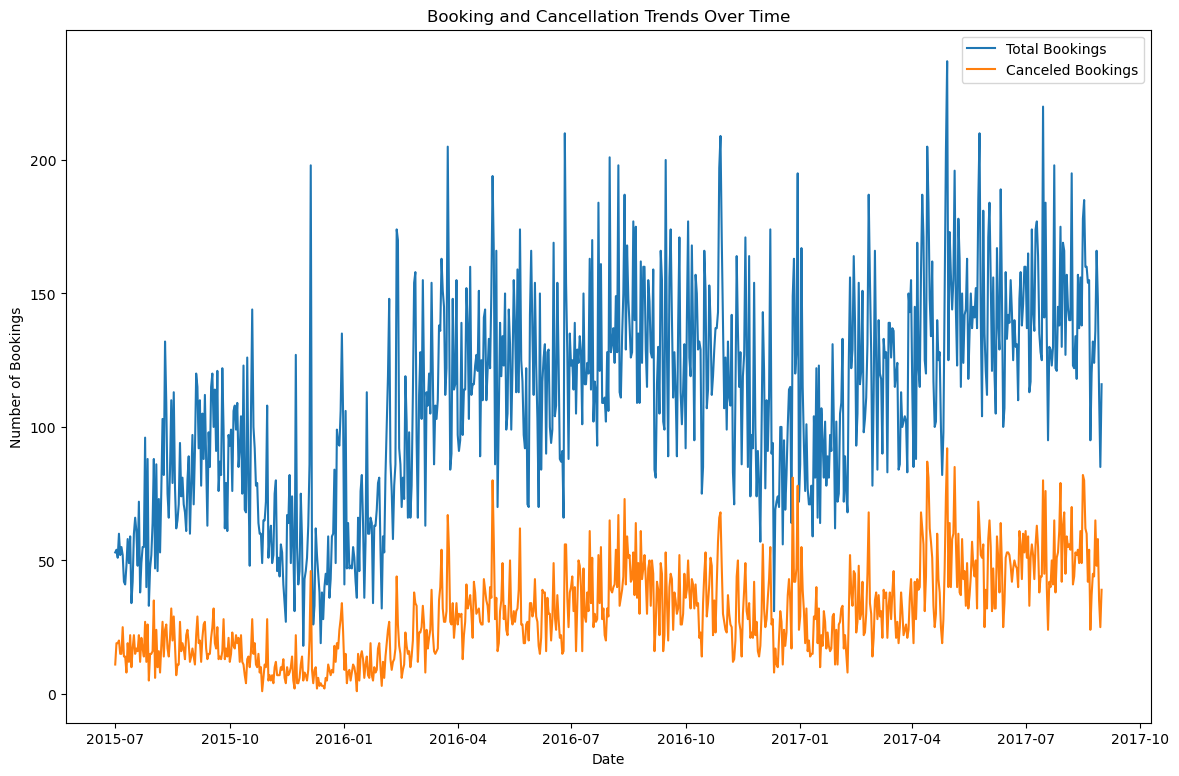

In [41]:
# Step 1: Create a new date column from year, month, and day
df['reservation_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)

#  Step 2: Group data by reservation date and calculate booking stats
daily = df.groupby('reservation_date')['is_canceled'].agg(['count', 'sum']).reset_index()
daily.columns = ['Date', 'Total_Bookings', 'Canceled_Bookings']

#  Step 3: Plot total bookings and canceled bookings over time
plt.figure(figsize=(14, 9))
sns.lineplot(data=daily, x='Date', y='Total_Bookings', label='Total Bookings')
sns.lineplot(data=daily, x='Date', y='Canceled_Bookings', label='Canceled Bookings')
plt.title('Booking and Cancellation Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Bookings')
plt.legend()
plt.show()

### Booking and Cancellation Trends Over Time

This chart shows how total bookings and cancellations change over time.  
We created a new `reservation_date` column using year, month, and day.  
Then we grouped data by this date to calculate:
- Total bookings
- Number of cancellations
Finally, we plotted both to see seasonal trends and booking behavior.

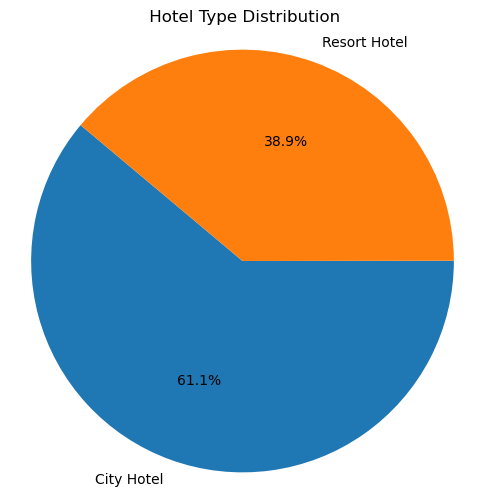

In [42]:
##1.Hotel Type Distribution
hotel_counts = df['hotel'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(hotel_counts, labels=hotel_counts.index, autopct='%1.1f%%', startangle=140)
plt.title(' Hotel Type Distribution')
plt.axis('equal')
plt.show()

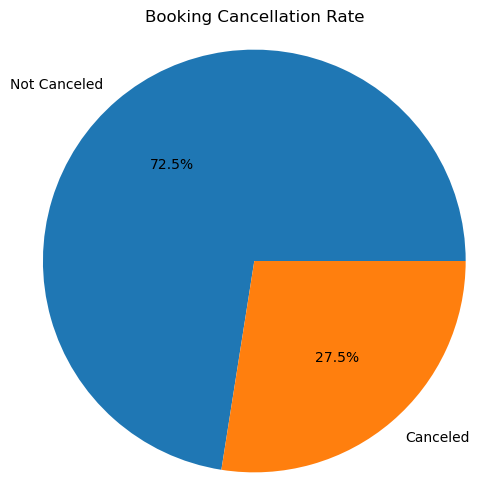

In [43]:
# 2. Booking Cancellation Rate
cancel_counts = df['is_canceled'].value_counts()
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6, 6))
plt.pie(cancel_counts, labels=labels, autopct='%1.1f%%')
plt.title('Booking Cancellation Rate')
plt.axis('equal')
plt.show()

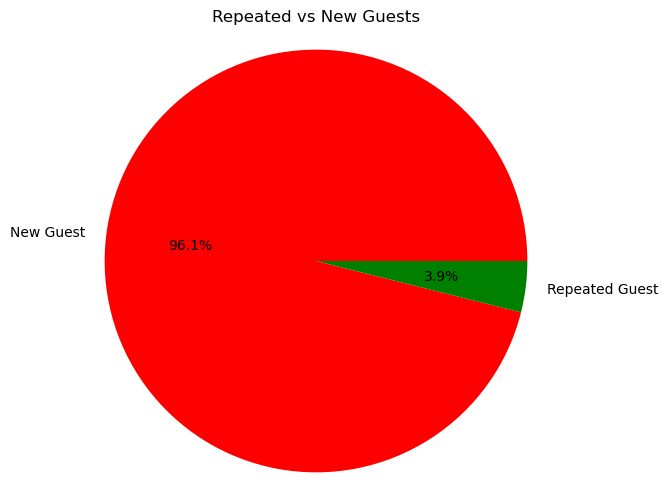

In [44]:
# 3. Repeated vs New Guests
repeat_counts = df['is_repeated_guest'].value_counts()
labels = ['New Guest', 'Repeated Guest']

plt.figure(figsize=(6, 6))
plt.pie(repeat_counts, labels=labels, autopct='%1.1f%%',colors=["red","green"])
plt.title('Repeated vs New Guests')
plt.axis('equal')
plt.show()

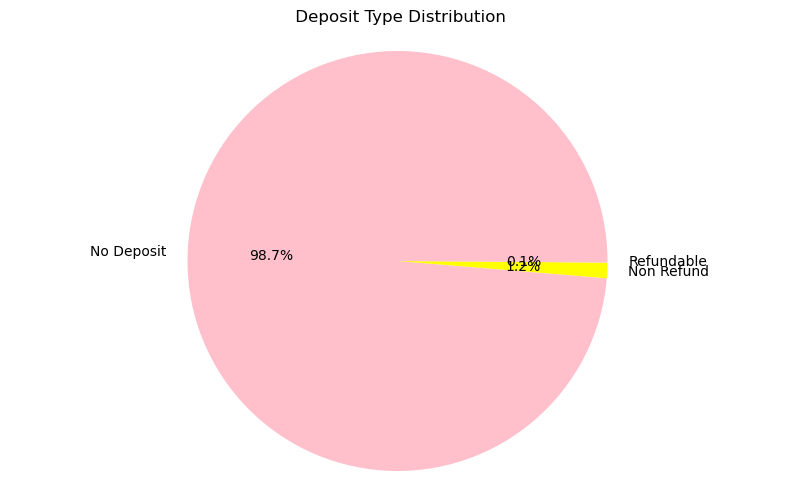

In [45]:
# 4. Deposit Type Distribution
deposit_counts = df['deposit_type'].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(deposit_counts, labels=deposit_counts.index, autopct='%1.1f%%',colors=["pink","yellow"])
plt.title(' Deposit Type Distribution')
plt.axis('equal')
plt.show()

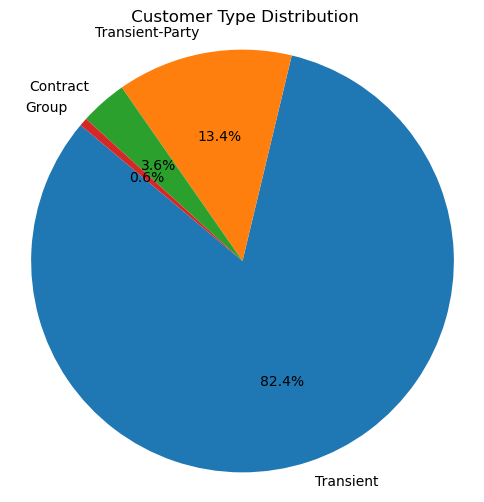

In [46]:
## 5. Customer Type Distribution
customer_counts = df['customer_type'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(customer_counts, labels=customer_counts.index, autopct='%1.1f%%', startangle=140)
plt.title(' Customer Type Distribution')
plt.axis('equal')
plt.show()

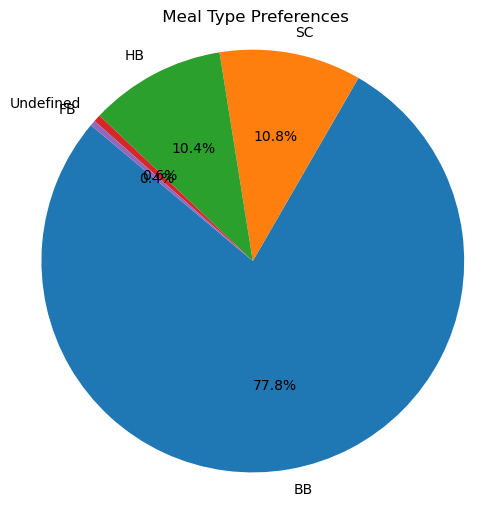

In [47]:
##  6. Meal Type Preference
meal_counts = df['meal'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(meal_counts, labels=meal_counts.index, autopct='%1.1f%%', startangle=140)
plt.title(' Meal Type Preferences')
plt.axis('equal')
plt.show()

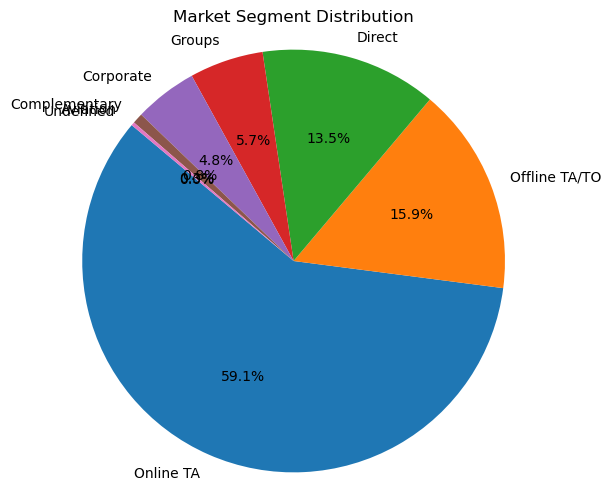

In [48]:
## 7. Market Segment
market_counts = df['market_segment'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(market_counts, labels=market_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Market Segment Distribution')
plt.axis('equal')
plt.show()

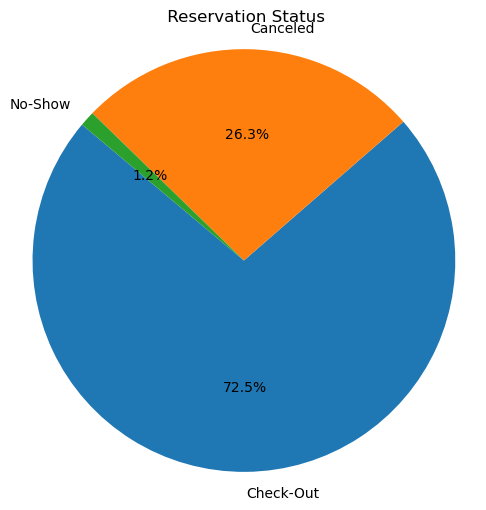

In [49]:
##  8. Reservation Status
status_counts = df['reservation_status'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140)
plt.title(' Reservation Status')
plt.axis('equal')
plt.show()

##  Pie Chart Summary

To get a quick overview of how certain categories are distributed in our hotel booking data, we created pie charts for key features. These visuals help us see which values are more common and how customers are spread across different groups.

### Charts We Created:

1. **Hotel Type** – To compare bookings between City Hotel and Resort Hotel.
2. **Meal Type** – To see which meal plans are most popular.
3. **Market Segment** – Shows how customers found the hotel (like Online, Corporate, etc.).
4. **Distribution Channel** – How the bookings were made (directly or through an agent).
5. **Deposit Type** – Whether guests paid a deposit or not.
6. **Customer Type** – Helps us understand guest profiles like transient or group bookings.
7. **Reservation Status** – Shows if the booking was canceled, checked out, or still active.
8. **Is Repeated Guest** – Tells us how many guests are returning customers.

These pie charts help us understand the dataset better by showing the proportion of each category in a simple, visual way.

In [50]:
### Lets Apply Groupby() to the neccesary data 

#### 1. Group by Hotel and Check Cancellation Rat
This shows the average cancellation rate (as a percentage) for each hotel.

In [51]:
# Cancellation rate per hotel type
df.groupby('hotel')['is_canceled'].mean()

hotel
City Hotel      0.300386
Resort Hotel    0.234809
Name: is_canceled, dtype: float64

#### 2.Group by Customer Type and ADR
Helps understand which customer type pays more per night.

In [52]:
# Average ADR per customer type
df.groupby('customer_type')['adr'].mean()

customer_type
Contract            92.753036
Group               84.361949
Transient          110.135859
Transient-Party     87.675056
Name: adr, dtype: float64

##### 3. Group by Market Segment and Count Bookings
Tells you which segment brings the most bookings.

In [53]:
# Total bookings per market segment
df.groupby('market_segment')['is_canceled'].count()

market_segment
Aviation           227
Complementary      702
Corporate         4212
Direct           11804
Groups            4942
Offline TA/TO    13889
Online TA        51618
Undefined            2
Name: is_canceled, dtype: int64

#### 4. Group by Hotel and Reservation Status
Gives a summary of how many bookings were canceled/completed for each hotel.

In [54]:
# Status distribution by hotel type
df.groupby(['hotel', 'reservation_status'])['reservation_status'].count()

hotel         reservation_status
City Hotel    Canceled              15301
              Check-Out             37379
              No-Show                 748
Resort Hotel  Canceled               7710
              Check-Out             25992
              No-Show                 266
Name: reservation_status, dtype: int64

#### 5. Group by Month and ADR
Helps find seasonal pricing trends.

In [55]:
# Monthly average rate
df.groupby('arrival_date_month')['adr'].mean().sort_values()

arrival_date_month
January       70.050742
November      72.754460
February      74.692033
December      81.450226
March         81.609523
October       90.152518
April        103.612589
May          111.195703
September    112.081263
June         119.750120
July         135.542014
August       150.876120
Name: adr, dtype: float64

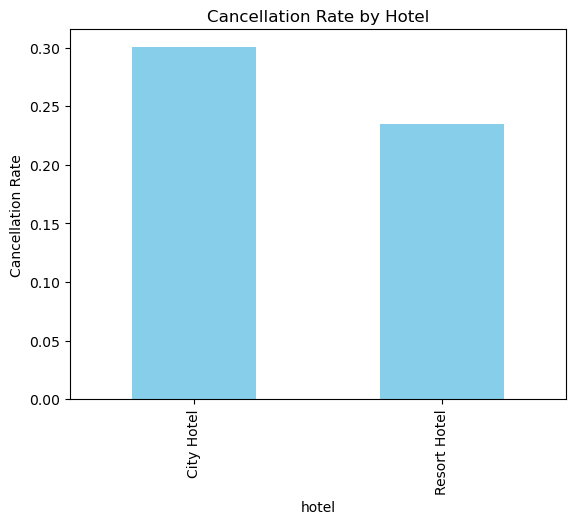

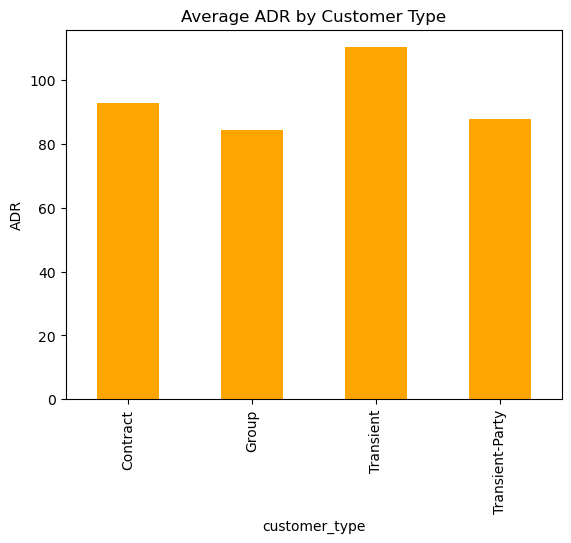

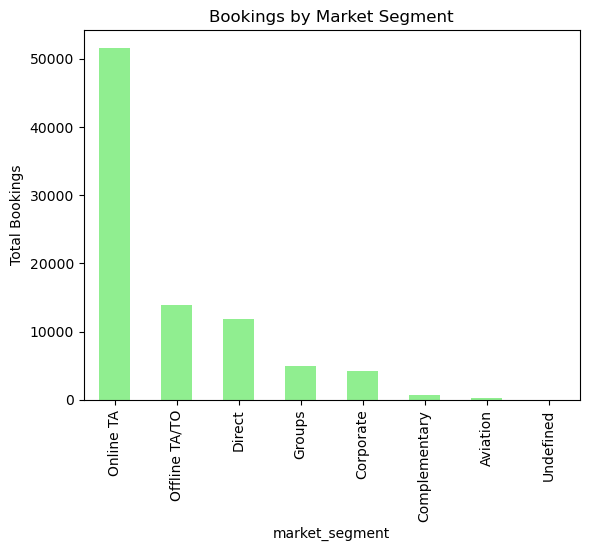

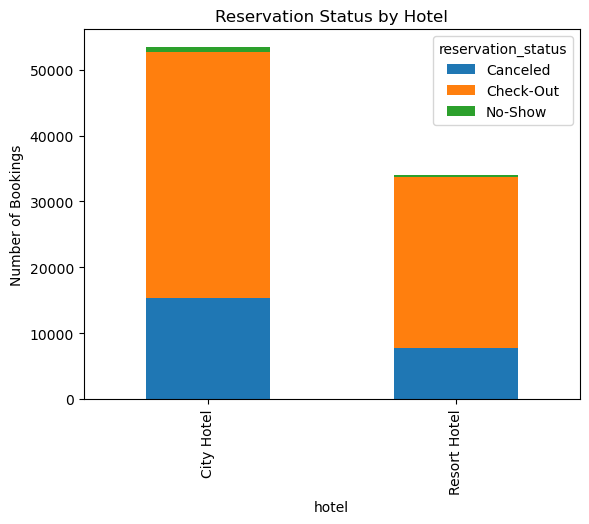

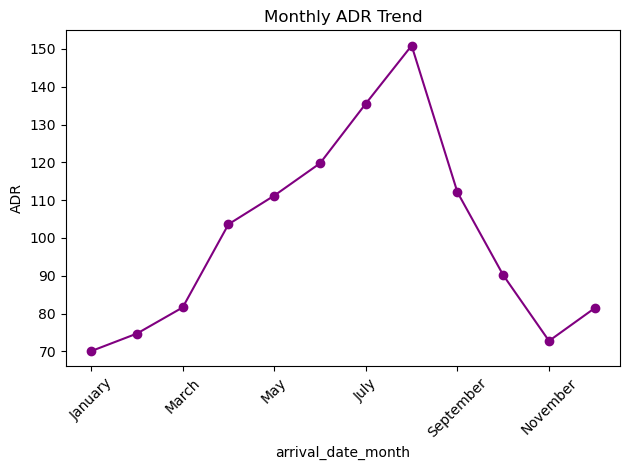

In [56]:
import calendar
# 1. Cancellation Rate by Hotel
plt.figure()
df.groupby('hotel')['is_canceled'].mean().plot(kind='bar', color='skyblue', title='Cancellation Rate by Hotel')
plt.ylabel('Cancellation Rate')
plt.show()

# 2. Average ADR by Customer Type
plt.figure()
df.groupby('customer_type')['adr'].mean().plot(kind='bar', color='orange', title='Average ADR by Customer Type')
plt.ylabel('ADR')
plt.show()

# 3. Total Bookings by Market Segment
plt.figure()
df['market_segment'].value_counts().plot(kind='bar', color='lightgreen', title='Bookings by Market Segment')
plt.ylabel('Total Bookings')
plt.show()

# 4. Reservation Status by Hotel (Stacked Bar)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, orange, green
df.groupby(['hotel', 'reservation_status']).size().unstack().plot(
    kind='bar', stacked=True, color=colors, title='Reservation Status by Hotel'
)
plt.ylabel('Number of Bookings')
plt.show()

# 5. Monthly ADR Trend
monthly_adr = df.groupby('arrival_date_month')['adr'].mean()
monthly_adr = monthly_adr.reindex(list(calendar.month_name)[1:])  # Sort months
monthly_adr.plot(kind='line', marker='o', color='purple', title='Monthly ADR Trend')
plt.ylabel('ADR')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###  Key Observations from Grouped Visualizations

#### 1. Cancellation Rate by Hotel Type
- City hotels show a **higher cancellation rate** compared to resort hotels.
- This could be due to flexible plans of city travelers or more frequent last-minute changes.
---
#### 2. Average ADR (Average Daily Rate) by Customer Type
- **Transient customers** tend to pay **higher room prices** than others.
- These may be individual travelers booking closer to their travel date or choosing better rooms.
---
#### 3. Total Bookings by Market Segment
- **Online Travel Agents (OTAs)** account for the **majority of bookings**.
- This indicates a strong dependency on third-party platforms by the hotel.
---
#### 4. Reservation Status by Hotel Type
- City hotels have more **canceled** and **checked-out** bookings than resort hotels.
- Indicates **higher booking activity and volatility** in city-based properties.
---
#### 5. Monthly ADR Trend
- The **ADR is highest in summer months**, especially **July and August**.
- This suggests seasonal demand, possibly due to holidays and vacations.

##  Key Observations & Conclusions

### 1. City Hotels are More Popular
City hotels had more bookings than resort hotels, showing that people prefer to stay in urban areas — possibly for work, convenience, or city attractions.

### 2.  Longer Lead Times Often Mean More Cancellations
Bookings made far in advance were more likely to be canceled. This shows that early plans can often change.

### 3.  Higher Cancellations at City Hotels
City hotels had more cancellations than resorts, which could be due to easier access or more flexible plans in cities.

### 4.  Summer is the Peak Season
Most bookings happened between May and August. These months are clearly the busiest, and hotels can plan their pricing and staffing around them.

### 5.  Low Need for Parking
Very few guests requested car parking, suggesting that many use public transport — especially in city locations.

### 6.  Most Bookings Are for 2 Adults
Most guests book rooms for two adults, with no children or babies. Couples seem to be the main customer group.

### 7.  Resort Hotels Charge More
Resort hotels had higher average daily rates (ADR) than city hotels. They may be offering luxury or vacation experiences.

### 8.  Special Requests = More Serious Guests
Guests who made special requests were less likely to cancel. This may show they are more committed or involved in their stay.

### 9.  Missing Info on Booking Agents
There was a lot of missing data for "agent" and "company". This makes it harder to analyze booking sources.

### 10.  Most Guests Are from Portugal
Portugal was the top country for bookings. Hotels can focus their marketing efforts there.

---

###  Final Thoughts
This project helped uncover real booking trends and customer behaviors. These insights can help hotel managers:
- Reduce last-minute cancellations
- Plan for busy seasons
- Understand what their guests need
- Make smarter decisions to grow their business

##  Business Recommendations

- **Reduce cancellations** by targeting guests with long lead times using confirmation emails or flexible policies.
- **Focus marketing efforts** in Portugal, as most guests are local.
- **Offer special deals for couples**, since most bookings are for 2 adults.
- **Plan staffing and pricing** for the high season (May to August).
- **Use special requests** as a loyalty indicator to improve customer service.

##  Final Conclusion (Simple & Clear)

In this project, we analyzed hotel booking data to understand how people book hotels, when they cancel, and what affects their choices. After cleaning the data and doing visual analysis, we discovered some useful insights.

### What We Found:
- City hotels are booked more often, but they also have more cancellations.
- People who book a long time in advance are more likely to cancel.
- Most bookings are for two adults, with very few children or babies.
- More bookings happen during the summer (May to August).
- Resort hotels are more expensive than city hotels.
- Guests who make special requests are more likely to show up.
- Most guests come from Portugal.
- Most bookings come from online travel websites.

### Why It Matters:
These findings can help hotel managers:
- Reduce cancellations by offering flexible booking options.
- Prepare better for busy seasons with enough staff and adjusted prices.
- Focus on couples and local travelers in their marketing.
- Treat guests with special requests as loyal and valuable customers.

### What We Learned:
This project helped us practice important data skills like cleaning messy data, finding patterns with visualizations, and turning numbers into business advice. It shows how data can help businesses make smart decisions and improve their services.